In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fontTools.subset import subset
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, RobustScaler
import sklearn.metrics as sm

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

#Datasets
from sklearn.datasets import fetch_california_housing, load_diabetes, load_wine, fetch_20newsgroups

#Our models
from src.linear_regression import LinearRegression
from src.linear_regression_gd import LinearRegressionGD
from src.ridge_regression import RidgeRegression
from src.lasso_regression import LassoRegression
from src.logistic_regression import LogisticRegression
from src.naive_bayes import GaussianNaiveBayes
from src.text_features import BagOfWords, TfidfTransformer

np.random.seed(42)
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

**Datasets**

In [3]:
df_california = fetch_california_housing(as_frame=True)

df_diabetes = load_diabetes(as_frame=True)

df_wine = load_wine(as_frame=True)

df_news_train = fetch_20newsgroups(
    subset = "train",
    categories = ["comp.graphics", "talk.religion.misc"],
    remove = ("headers", "footers", "quotes"),
    random_state=42
)

df_news_test = fetch_20newsgroups(
    subset = "test",
    categories = ["comp.graphics", "talk.religion.misc"],
    remove = ("headers", "footers", "quotes"),
    random_state=42
)

In [4]:
print(df_california)

{'data':        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  
0        -1

In [5]:
rng = np.random.default_rng(42)
X = rng.normal(size=(100, 5))
y = rng.normal(size=100)

ols = LinearRegression().fit(X, y)
print(ols.intercept_)
print(ols.coef_)

-0.09032442458343276
[-0.08198981 -0.05326486 -0.0622452  -0.0599291   0.06706994]


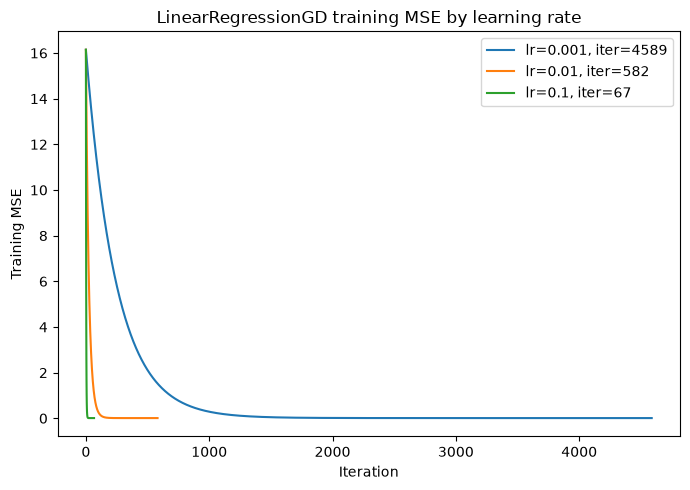

In [6]:
rng = np.random.default_rng(42)
N, p = 1000, 10
X = rng.normal(size=(N, p))
true_weights = rng.normal(size=p)
y = 2.0 + X @ true_weights + rng.normal(scale=0.1, size=N)

learning_rates = [0.001, 0.01, 0.1]
plt.figure(figsize=(7, 5))
for lr in learning_rates:
    model = LinearRegressionGD(lr=lr, max_iter=5000, tol=1e-6).fit(X, y)
    plt.plot(model.mse_history_, label=f"lr={lr}, iter={model.n_iter_}")

plt.xlabel("Iteration")
plt.ylabel("Training MSE")
plt.title("LinearRegressionGD training MSE by learning rate")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "part1_gd_mse.pdf", dpi=300)
plt.show()

**Polynomial fitting on California Housing dataset**

Best validation degree: 8


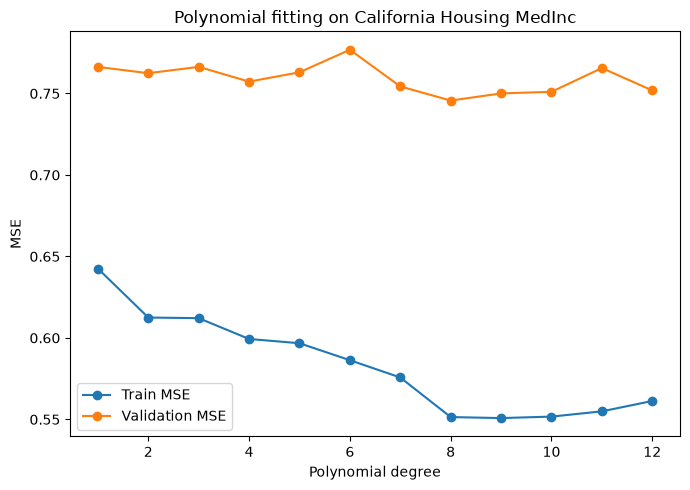

In [7]:
X_medinc = df_california.frame[["MedInc"]].to_numpy()
y_house = df_california.target

X_train, X_val, y_train, y_val = train_test_split(
    X_medinc, y_house, train_size=100, test_size=100, random_state=42
)

def polynomial_design(x, degree):
    x = np.asarray(x).reshape(-1)
    return np.column_stack([x ** d for d in range(1, degree + 1)])

train_mse = []
val_mse = []
degrees = range(1, 13)

for degree in degrees:
    Phi_train = polynomial_design(X_train, degree)
    Phi_val = polynomial_design(X_val, degree)

    mean = Phi_train.mean(axis=0)
    scale = Phi_train.std(axis=0)
    scale[scale == 0] = 1.0
    Phi_train_scaled = (Phi_train - mean) / scale
    Phi_val_scaled = (Phi_val - mean) / scale

    model = LinearRegression().fit(Phi_train_scaled, y_train)
    train_mse.append(sm.mean_squared_error(y_train, model.predict(Phi_train_scaled)))
    val_mse.append(sm.mean_squared_error(y_val, model.predict(Phi_val_scaled)))

best_degree = list(degrees)[int(np.argmin(val_mse))]
print("Best validation degree:", best_degree)

plt.figure(figsize=(7, 5))
plt.plot(list(degrees), train_mse, marker="o", label="Train MSE")
plt.plot(list(degrees), val_mse, marker="o", label="Validation MSE")
plt.xlabel("Polynomial degree")
plt.ylabel("MSE")
plt.title("Polynomial fitting on California Housing MedInc")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "part1_polynomial_overfitting.pdf", dpi=300)
plt.show()

**PREDICTION INTERVALS**

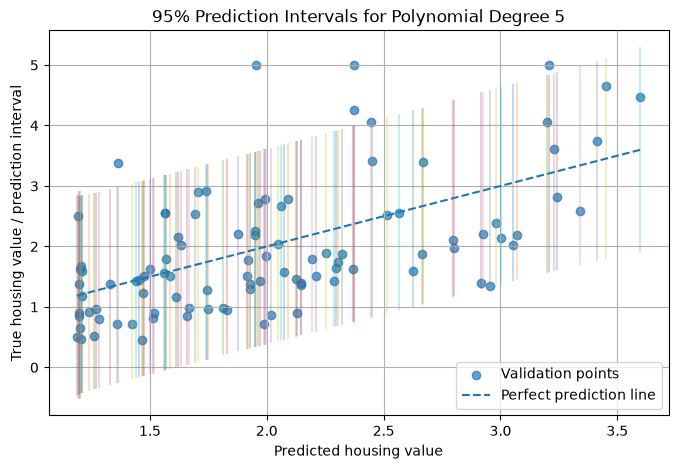

Degree 5 average interval width: 3.2176


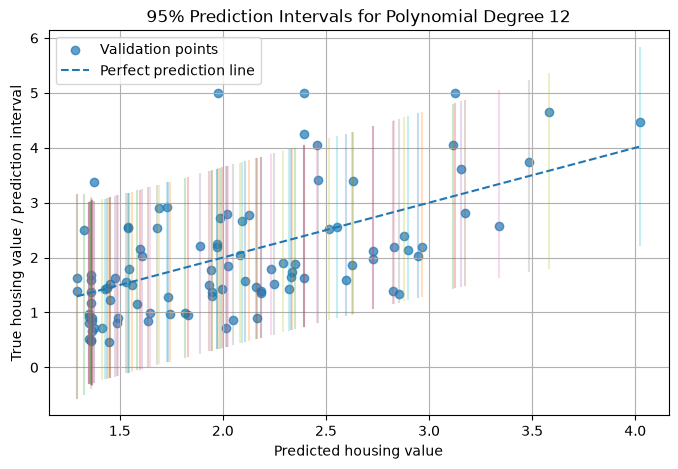

Degree 12 average interval width: 3.2960


In [8]:
from scipy.stats import t

housing = fetch_california_housing()
X_medinc = housing.data[:, [housing.feature_names.index("MedInc")]]
y = housing.target

X_train_full, X_val_full, y_train, y_val = train_test_split(
    X_medinc,
    y,
    train_size=100,
    test_size=100,
    random_state=42
)

def polynomial_features(x, degree):
    return np.hstack([x ** power for power in range(1, degree + 1)])

def fit_polynomial_with_intervals(degree):
    X_train_poly = polynomial_features(X_train_full, degree)
    X_val_poly = polynomial_features(X_val_full, degree)

    mean = X_train_poly.mean(axis=0)
    std = X_train_poly.std(axis=0)
    std[std == 0] = 1

    X_train_scaled = (X_train_poly - mean) / std
    X_val_scaled = (X_val_poly - mean) / std

    model = LinearRegression()
    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_val_pred = model.predict(X_val_scaled)

    X_train_aug = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
    X_val_aug = np.c_[np.ones(X_val_scaled.shape[0]), X_val_scaled]

    n = X_train_aug.shape[0]
    p = X_train_aug.shape[1]

    residuals = y_train - y_train_pred
    sigma_squared = np.sum(residuals ** 2) / (n - p)

    xtx = X_train_aug.T @ X_train_aug

    try:
        xtx_inv = np.linalg.inv(xtx)
    except np.linalg.LinAlgError:
        xtx_inv = np.linalg.pinv(xtx)

    t_value = t.ppf(0.975, df=n - p)

    interval_terms = []
    for x_star in X_val_aug:
        value = x_star.T @ xtx_inv @ x_star
        interval = t_value * np.sqrt(sigma_squared * (1 + value))
        interval_terms.append(interval)

    interval_terms = np.array(interval_terms)

    lower = y_val_pred - interval_terms
    upper = y_val_pred + interval_terms
    avg_width = np.mean(upper - lower)

    return y_val_pred, lower, upper, avg_width

results = {}

for degree in [5, 12]:
    y_pred, lower, upper, avg_width = fit_polynomial_with_intervals(degree)
    results[degree] = {
        "pred": y_pred,
        "lower": lower,
        "upper": upper,
        "avg_width": avg_width
    }

    order = np.argsort(y_pred)

    plt.figure(figsize=(8, 5))
    plt.scatter(y_pred, y_val, alpha=0.7, label="Validation points")

    for i in order:
        plt.plot(
            [y_pred[i], y_pred[i]],
            [lower[i], upper[i]],
            alpha=0.25
        )

    plt.plot(
        [y_pred.min(), y_pred.max()],
        [y_pred.min(), y_pred.max()],
        linestyle="--",
        label="Perfect prediction line"
    )

    plt.xlabel("Predicted housing value")
    plt.ylabel("True housing value / prediction interval")
    plt.title(f"95% Prediction Intervals for Polynomial Degree {degree}")
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Degree {degree} average interval width: {avg_width:.4f}")

**Ridge and Lasso coefficients paths on Diabetes**

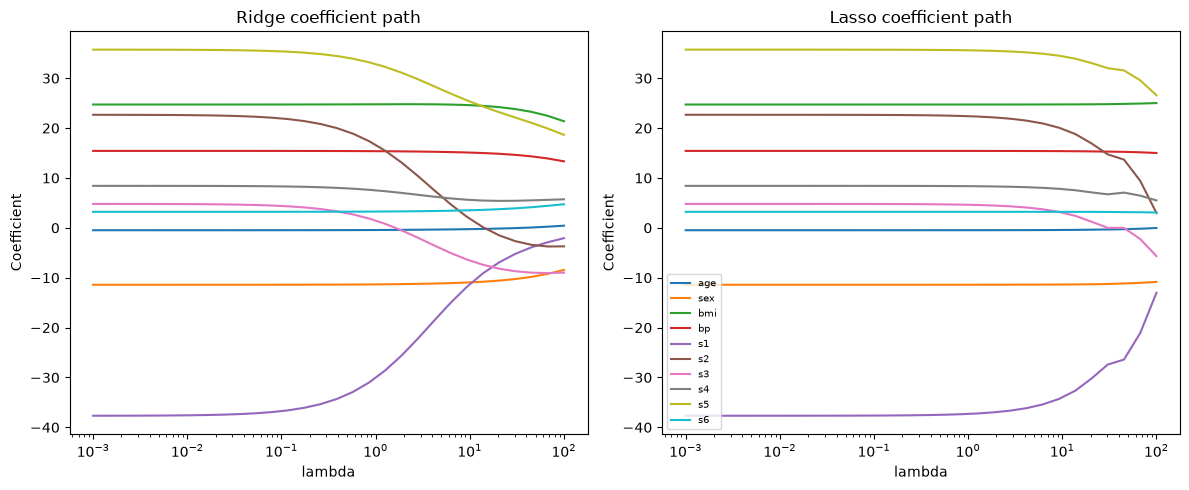

In [9]:
X_diabetes = df_diabetes.data.to_numpy()
y_diabetes = df_diabetes.target.to_numpy()

scaler = StandardScaler()
X_diabetes_scaled = scaler.fit_transform(X_diabetes)

lambdas = np.logspace(-3, 2, 30)
ridge_coefs = []
lasso_coefs = []

for lambda_ in lambdas:
    ridge = RidgeRegression(lambda_=lambda_).fit(X_diabetes_scaled, y_diabetes)
    lasso = LassoRegression(lambda_=lambda_, max_iter=10000, tol=1e-4).fit(X_diabetes_scaled, y_diabetes)
    ridge_coefs.append(ridge.coef_)
    lasso_coefs.append(lasso.coef_)

ridge_coefs = np.vstack(ridge_coefs)
lasso_coefs = np.vstack(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for j, name in enumerate(df_diabetes.feature_names):
    axes[0].plot(lambdas, ridge_coefs[:, j], label=name)
    axes[1].plot(lambdas, lasso_coefs[:, j], label=name)

axes[0].set_xscale("log")
axes[1].set_xscale("log")
axes[0].set_xlabel("lambda")
axes[1].set_xlabel("lambda")
axes[0].set_ylabel("Coefficient")
axes[1].set_ylabel("Coefficient")
axes[0].set_title("Ridge coefficient path")
axes[1].set_title("Lasso coefficient path")
axes[1].legend(fontsize=7, loc="best")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "part2_diabetes_coefficient_paths.pdf", dpi=300)
plt.show()

**HYPERPARAMETER SEARCH**

,Strategy,Best lambda,Validation RMSE at best,Wall-clock time (sec)
0,Grid search,11.288379,0.728231,0.385924
1,Random search,14.155361,0.728229,0.384509


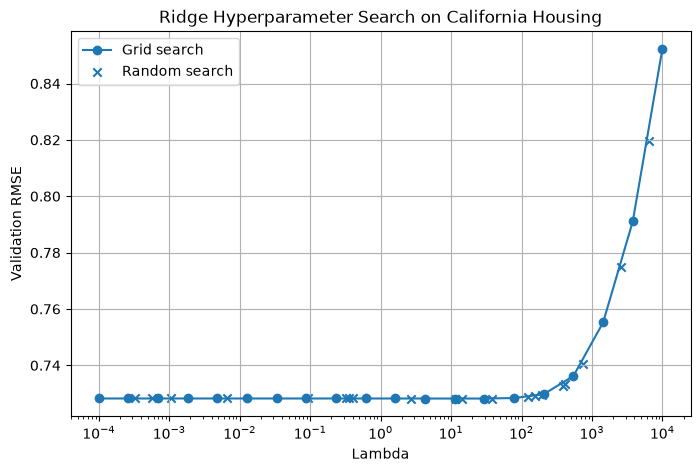

Best strategy: random search
Best lambda for learning curves: 14.155361


In [10]:
import time

housing = fetch_california_housing()
X = housing.data
y = housing.target


def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def standardize_train_val(X_train, X_val):
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)
    std[std == 0] = 1

    X_train_scaled = (X_train - mean) / std
    X_val_scaled = (X_val - mean) / std

    return X_train_scaled, X_val_scaled


def cv_rmse_for_lambda(lambda_value, X, y, cv):
    scores = []

    for train_idx, val_idx in cv.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        X_train_scaled, X_val_scaled = standardize_train_val(X_train, X_val)

        model = RidgeRegression(lambda_=lambda_value)
        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_val_scaled)
        scores.append(rmse(y_val, y_pred))

    return np.mean(scores)


cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_lambdas = np.logspace(-4, 4, 20)

rng = np.random.default_rng(42)
random_lambdas = 10 ** rng.uniform(-4, 4, size=20)


def run_search(lambdas):
    start_time = time.perf_counter()

    validation_rmses = []
    for lambda_value in lambdas:
        validation_rmses.append(cv_rmse_for_lambda(lambda_value, X, y, cv))

    wall_clock_time = time.perf_counter() - start_time

    validation_rmses = np.array(validation_rmses)
    best_index = np.argmin(validation_rmses)

    return {
        "lambdas": np.array(lambdas),
        "rmses": validation_rmses,
        "best_lambda": lambdas[best_index],
        "best_rmse": validation_rmses[best_index],
        "time": wall_clock_time
    }


grid_result = run_search(grid_lambdas)
random_result = run_search(random_lambdas)

summary_df = pd.DataFrame({
    "Strategy": ["Grid search", "Random search"],
    "Best lambda": [grid_result["best_lambda"], random_result["best_lambda"]],
    "Validation RMSE at best": [grid_result["best_rmse"], random_result["best_rmse"]],
    "Wall-clock time (sec)": [grid_result["time"], random_result["time"]]
})

display(summary_df)

plt.figure(figsize=(8, 5))
plt.plot(
    grid_result["lambdas"],
    grid_result["rmses"],
    marker="o",
    label="Grid search"
)
plt.scatter(
    random_result["lambdas"],
    random_result["rmses"],
    marker="x",
    label="Random search"
)

plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("Validation RMSE")
plt.title("Ridge Hyperparameter Search on California Housing")
plt.legend()
plt.grid(True)
plt.savefig(FIGURES_DIR / "part2_ridge_hyperparameter_search.pdf", bbox_inches="tight")
plt.show()

if grid_result["best_rmse"] <= random_result["best_rmse"]:
    best_lambda_for_learning = grid_result["best_lambda"]
    best_strategy_name = "grid search"
else:
    best_lambda_for_learning = random_result["best_lambda"]
    best_strategy_name = "random search"

print(f"Best strategy: {best_strategy_name}")
print(f"Best lambda for learning curves: {best_lambda_for_learning:.6f}")

**LEARNING CURVES**

,Training size,OLS train RMSE,OLS validation RMSE,Ridge train RMSE,Ridge validation RMSE
0,100,0.508098,0.883264,0.555731,0.865514
1,500,0.656759,0.768285,0.665261,0.771367
2,1000,0.660180,0.774848,0.662763,0.777390
3,5000,0.718567,0.740293,0.718691,0.739554
4,16512,0.719676,0.745581,0.719688,0.745247


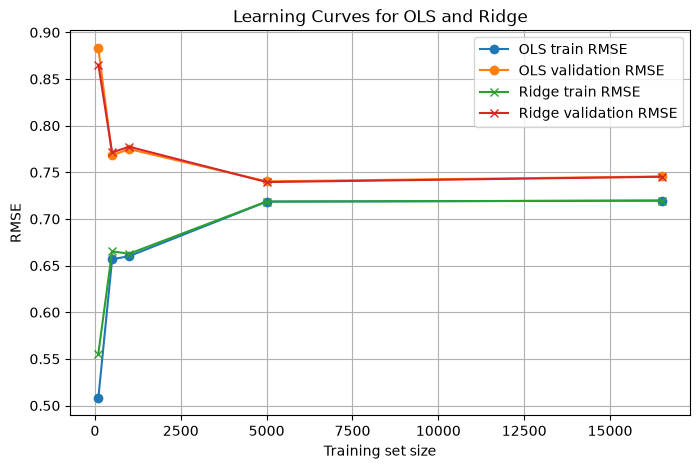

Final training size results:
OLS validation RMSE: 0.7456
Ridge validation RMSE: 0.7452


In [11]:
X_train_all, X_val, y_train_all, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

train_sizes = [100, 500, 1000, 5000, len(X_train_all)]

learning_rows = []

for train_size in train_sizes:
    X_train = X_train_all[:train_size]
    y_train = y_train_all[:train_size]

    X_train_scaled, X_val_scaled = standardize_train_val(X_train, X_val)

    ols_model = LinearRegression()
    ols_model.fit(X_train_scaled, y_train)

    ridge_model = RidgeRegression(lambda_=best_lambda_for_learning)
    ridge_model.fit(X_train_scaled, y_train)

    learning_rows.append({
        "Training size": train_size,
        "OLS train RMSE": rmse(y_train, ols_model.predict(X_train_scaled)),
        "OLS validation RMSE": rmse(y_val, ols_model.predict(X_val_scaled)),
        "Ridge train RMSE": rmse(y_train, ridge_model.predict(X_train_scaled)),
        "Ridge validation RMSE": rmse(y_val, ridge_model.predict(X_val_scaled))
    })

learning_df = pd.DataFrame(learning_rows)
display(learning_df)

plt.figure(figsize=(8, 5))

plt.plot(
    learning_df["Training size"],
    learning_df["OLS train RMSE"],
    marker="o",
    label="OLS train RMSE"
)
plt.plot(
    learning_df["Training size"],
    learning_df["OLS validation RMSE"],
    marker="o",
    label="OLS validation RMSE"
)
plt.plot(
    learning_df["Training size"],
    learning_df["Ridge train RMSE"],
    marker="x",
    label="Ridge train RMSE"
)
plt.plot(
    learning_df["Training size"],
    learning_df["Ridge validation RMSE"],
    marker="x",
    label="Ridge validation RMSE"
)

plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.title("Learning Curves for OLS and Ridge")
plt.legend()
plt.grid(True)
plt.savefig(FIGURES_DIR / "part2_learning_curves.pdf", bbox_inches="tight")
plt.show()

last_row = learning_df.iloc[-1]

print("Final training size results:")
print(f"OLS validation RMSE: {last_row['OLS validation RMSE']:.4f}")
print(f"Ridge validation RMSE: {last_row['Ridge validation RMSE']:.4f}")

Multiclass Logistic Regression vs Gaussian NB on Wine dataset

In [12]:
X_wine = df_wine.data.to_numpy()
y_wine = df_wine.target.to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(lr=0.1, lambda_=0.01, max_iter=5000).fit(X_train_scaled, y_train)
nb_model = GaussianNaiveBayes().fit(X_train_scaled, y_train)

for name, model in [("Logistic Regression", lr_model), ("Gaussian NB", nb_model)]:
    pred = model.predict(X_test_scaled)
    print(name)
    print("accuracy:", sm.accuracy_score(y_test, pred))
    print("precision:", sm.precision_score(y_test, pred, average="macro"))
    print("recall:", sm.recall_score(y_test, pred, average="macro"))
    print("f1:", sm.f1_score(y_test, pred, average="macro"))
    print(sm.confusion_matrix(y_test, pred))
    print("-"*50)

Logistic Regression
accuracy: 1.0
precision: 1.0
recall: 1.0
f1: 1.0
[[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]
--------------------------------------------------
Gaussian NB
accuracy: 0.9722222222222222
precision: 0.9743589743589745
recall: 0.9761904761904763
f1: 0.974320987654321
[[12  0  0]
 [ 1 13  0]
 [ 0  0 10]]
--------------------------------------------------


**Text Classification Features**

In [13]:
bow = BagOfWords(max_features=5000).fit(df_news_train.data)

X_train_counts = bow.transform(df_news_train.data)
X_test_counts = bow.transform(df_news_test.data)

tfidf = TfidfTransformer().fit(X_train_counts)

X_train_tfidf = tfidf.transform(X_train_counts)
X_test_tfidf = tfidf.transform(X_test_counts)

y_train = df_news_train.target
y_test = df_news_test.target

text_lr = LogisticRegression(
    lr=0.1,
    lambda_=0.01,
    max_iter=1000
).fit(X_train_tfidf, y_train)

text_nb = GaussianNaiveBayes().fit(X_train_tfidf, y_train)

results = {}

for name, model in [
    ("Logistic Regression", text_lr),
    ("Gaussian NB", text_nb)
]:
    pred = model.predict(X_test_tfidf)
    proba = model.predict_proba(X_test_tfidf)[:, 1]

    f1 = sm.f1_score(y_test, pred)
    auc = sm.roc_auc_score(y_test, proba)

    results[name] = {
        "f1": f1,
        "auc": auc,
        "proba": proba
    }

    print(name)
    print("F1:", round(f1, 4))
    print("AUC:", round(auc, 4))
    print()

Logistic Regression
F1: 0.9151
AUC: 0.9789

Gaussian NB
F1: 0.8936
AUC: 0.9152



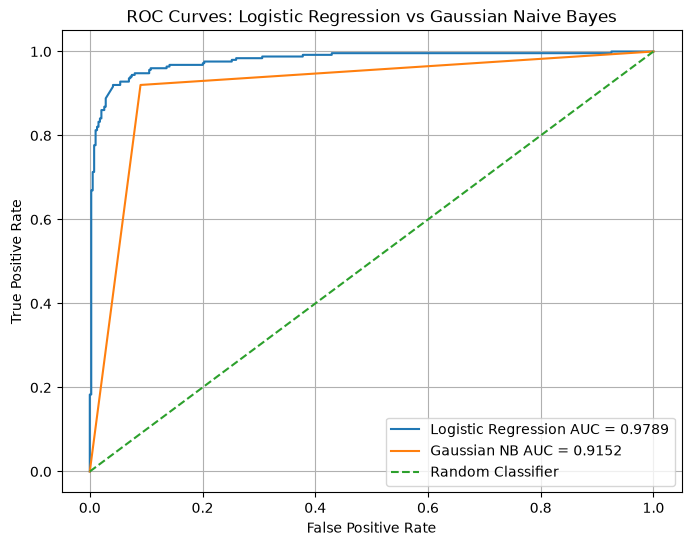

In [14]:
plt.figure(figsize=(8, 6))

for name, values in results.items():
    proba = values["proba"]
    auc = values["auc"]

    fpr, tpr, thresholds = sm.roc_curve(y_test, proba)

    plt.plot(fpr, tpr, label=f"{name} AUC = {auc:.4f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Logistic Regression vs Gaussian Naive Bayes")
plt.legend()
plt.grid(True)
plt.savefig(FIGURES_DIR / "part3_text_roc.pdf", dpi=300)
plt.show()

**CALIFORNIA HOUSING REGULARIZATION PATHS**
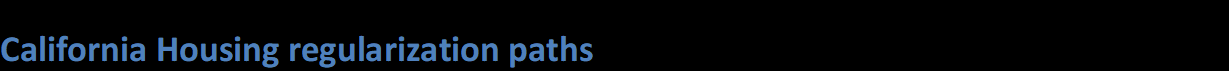

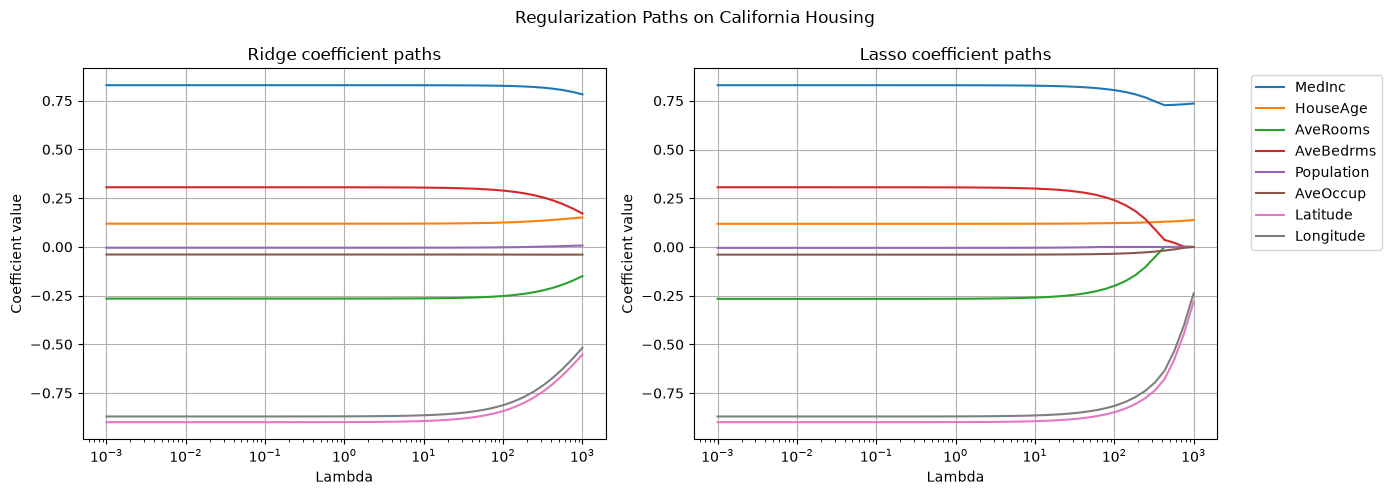

Correlation between AveRooms and AveBedrms: 0.8476


,lambda,Ridge AveRooms,Ridge AveBedrms,Lasso AveRooms,Lasso AveBedrms,Lasso nonzero coefficients
0,0.001000,-0.265527,0.305696,-0.266260,0.306267,8
1,0.091030,-0.265515,0.305681,-0.266200,0.306207,8
2,0.868511,-0.265414,0.305547,-0.265682,0.305690,8
3,10.985411,-0.264094,0.303812,-0.258939,0.298969,8
4,104.811313,-0.251640,0.287901,-0.196717,0.236727,7
5,1000.000000,-0.150238,0.171096,0.000000,0.000000,4


,Feature,Ridge coefficient at largest lambda,Lasso coefficient at largest lambda
0,MedInc,0.782467,0.736018
1,HouseAge,0.150684,0.138441
2,AveRooms,-0.150238,0.000000
3,AveBedrms,0.171096,0.000000
4,Population,0.006868,0.000000
5,AveOccup,-0.039700,0.000000
6,Latitude,-0.552891,-0.280661
7,Longitude,-0.518013,-0.237961


In [15]:
housing = fetch_california_housing()
X = housing.data
y = housing.target
feature_names = np.array(housing.feature_names)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lambdas = np.logspace(-3, 3, 50)

ridge_coefs = []
lasso_coefs = []


def get_coefficients(model, n_features):
    if hasattr(model, "coef_"):
        return np.ravel(model.coef_)

    if hasattr(model, "weights_standardized_"):
        return np.ravel(model.weights_standardized_)

    if hasattr(model, "weights_"):
        weights = np.ravel(model.weights_)

        if len(weights) == n_features + 1:
            return weights[1:]

        return weights

    raise AttributeError("Could not find coefficients in the model.")


for lambda_value in lambdas:
    ridge = RidgeRegression(lambda_=lambda_value)
    ridge.fit(X_scaled, y)
    ridge_coefs.append(get_coefficients(ridge, X_scaled.shape[1]))

    lasso = LassoRegression(lambda_=lambda_value, max_iter=10000, tol=1e-4)
    lasso.fit(X_scaled, y)
    lasso_coefs.append(get_coefficients(lasso, X_scaled.shape[1]))

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for j, feature in enumerate(feature_names):
    axes[0].plot(lambdas, ridge_coefs[:, j], label=feature)

axes[0].set_xscale("log")
axes[0].set_xlabel("Lambda")
axes[0].set_ylabel("Coefficient value")
axes[0].set_title("Ridge coefficient paths")
axes[0].grid(True)

for j, feature in enumerate(feature_names):
    axes[1].plot(lambdas, lasso_coefs[:, j], label=feature)

axes[1].set_xscale("log")
axes[1].set_xlabel("Lambda")
axes[1].set_ylabel("Coefficient value")
axes[1].set_title("Lasso coefficient paths")
axes[1].grid(True)

axes[1].legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.suptitle("Regularization Paths on California Housing")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "part4_california_regularization_paths.pdf", bbox_inches="tight")
plt.show()

# Correlation between AveRooms and AveBedrms
ave_rooms_idx = list(feature_names).index("AveRooms")
ave_bedrms_idx = list(feature_names).index("AveBedrms")

corr = np.corrcoef(X_scaled[:, ave_rooms_idx], X_scaled[:, ave_bedrms_idx])[0, 1]

print(f"Correlation between AveRooms and AveBedrms: {corr:.4f}")

# Show coefficients for selected lambda values
selected_lambdas = [1e-3, 1e-1, 1, 10, 100, 1000]

rows = []

for selected_lambda in selected_lambdas:
    idx = np.argmin(np.abs(lambdas - selected_lambda))

    rows.append({
        "lambda": lambdas[idx],
        "Ridge AveRooms": ridge_coefs[idx, ave_rooms_idx],
        "Ridge AveBedrms": ridge_coefs[idx, ave_bedrms_idx],
        "Lasso AveRooms": lasso_coefs[idx, ave_rooms_idx],
        "Lasso AveBedrms": lasso_coefs[idx, ave_bedrms_idx],
        "Lasso nonzero coefficients": np.sum(np.abs(lasso_coefs[idx]) > 1e-6)
    })

path_summary_df = pd.DataFrame(rows)
display(path_summary_df)

# Show final coefficients at largest lambda
largest_lambda_idx = -1

final_coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Ridge coefficient at largest lambda": ridge_coefs[largest_lambda_idx],
    "Lasso coefficient at largest lambda": lasso_coefs[largest_lambda_idx]
})

display(final_coef_df)

**ROC AND CALIBRATION**

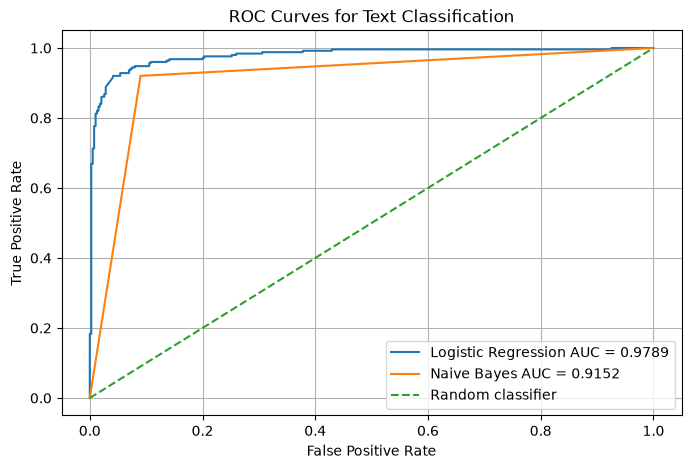

Logistic Regression AUC: 0.9789
Naive Bayes AUC: 0.9152
Logistic Regression ECE: 0.0312
Naive Bayes ECE: 0.0859

Logistic Regression calibration table:


,bin_start,bin_end,mean_predicted_probability,empirical_accuracy,count,absolute_gap
0,0.0,0.1,0.010396,0.019355,310,0.008959
1,0.1,0.2,0.144654,0.111111,36,0.033543
2,0.2,0.3,0.253573,0.200000,15,0.053573
3,0.3,0.4,0.350067,0.187500,16,0.162567
4,0.4,0.5,0.459731,0.451613,31,0.008118
5,0.5,0.6,0.543203,0.714286,14,0.171082
6,0.6,0.7,0.651804,0.823529,17,0.171725
7,0.7,0.8,0.738317,0.913043,23,0.174726
8,0.8,0.9,0.840472,0.944444,18,0.103973
9,0.9,1.0,0.986867,0.993750,160,0.006883



Naive Bayes calibration table:


,bin_start,bin_end,mean_predicted_probability,empirical_accuracy,count,absolute_gap
0,0.0,0.1,0.0,0.053476,374,0.053476
1,0.9,1.0,1.0,0.868421,266,0.131579


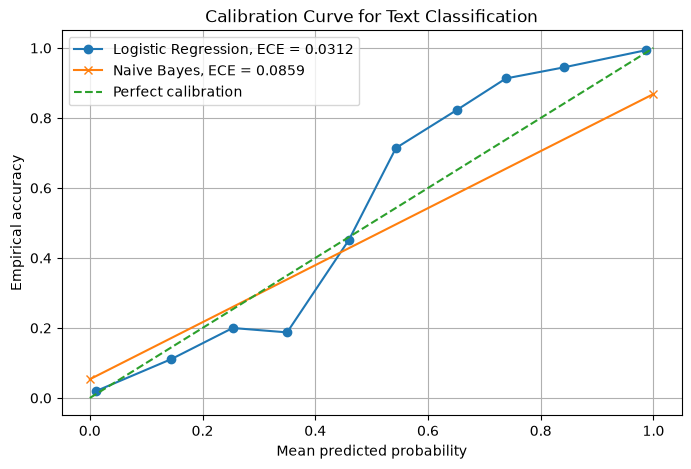

In [17]:
from sklearn.metrics import roc_curve, auc

def get_positive_class_proba(model, X):
    """
    Returns probability for class 1.
    Works directly if the model has predict_proba.
    """
    proba = model.predict_proba(X)

    if proba.ndim == 2:
        return proba[:, 1]

    return proba


def calibration_table(y_true, y_proba, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    rows = []

    for i in range(n_bins):
        left = bins[i]
        right = bins[i + 1]

        if i == n_bins - 1:
            mask = (y_proba >= left) & (y_proba <= right)
        else:
            mask = (y_proba >= left) & (y_proba < right)

        if np.sum(mask) == 0:
            continue

        mean_predicted_probability = np.mean(y_proba[mask])
        empirical_accuracy = np.mean(y_true[mask])
        count = np.sum(mask)

        rows.append({
            "bin_start": left,
            "bin_end": right,
            "mean_predicted_probability": mean_predicted_probability,
            "empirical_accuracy": empirical_accuracy,
            "count": count,
            "absolute_gap": abs(mean_predicted_probability - empirical_accuracy)
        })

    return pd.DataFrame(rows)


def expected_calibration_error(calib_df, total_count):
    weighted_error = (
        calib_df["count"] * calib_df["absolute_gap"]
    ).sum() / total_count

    return weighted_error


y_test = np.array(df_news_test.target)

lr_proba = get_positive_class_proba(text_lr, X_test_tfidf)
nb_proba = get_positive_class_proba(text_nb, X_test_tfidf)

# ROC curves
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_proba)
nb_fpr, nb_tpr, _ = roc_curve(y_test, nb_proba)

lr_auc = auc(lr_fpr, lr_tpr)
nb_auc = auc(nb_fpr, nb_tpr)

plt.figure(figsize=(8, 5))
plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression AUC = {lr_auc:.4f}")
plt.plot(nb_fpr, nb_tpr, label=f"Naive Bayes AUC = {nb_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Text Classification")
plt.legend()
plt.grid(True)
plt.savefig(FIGURES_DIR / "part4_text_roc_curves.pdf", bbox_inches="tight")
plt.show()

# Calibration tables
lr_calib = calibration_table(y_test, lr_proba, n_bins=10)
nb_calib = calibration_table(y_test, nb_proba, n_bins=10)

lr_ece = expected_calibration_error(lr_calib, len(y_test))
nb_ece = expected_calibration_error(nb_calib, len(y_test))

print(f"Logistic Regression AUC: {lr_auc:.4f}")
print(f"Naive Bayes AUC: {nb_auc:.4f}")
print(f"Logistic Regression ECE: {lr_ece:.4f}")
print(f"Naive Bayes ECE: {nb_ece:.4f}")

print("\nLogistic Regression calibration table:")
display(lr_calib)

print("\nNaive Bayes calibration table:")
display(nb_calib)

# Calibration plot
plt.figure(figsize=(8, 5))

plt.plot(
    lr_calib["mean_predicted_probability"],
    lr_calib["empirical_accuracy"],
    marker="o",
    label=f"Logistic Regression, ECE = {lr_ece:.4f}"
)

plt.plot(
    nb_calib["mean_predicted_probability"],
    nb_calib["empirical_accuracy"],
    marker="x",
    label=f"Naive Bayes, ECE = {nb_ece:.4f}"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

plt.xlabel("Mean predicted probability")
plt.ylabel("Empirical accuracy")
plt.title("Calibration Curve for Text Classification")
plt.legend()
plt.grid(True)
plt.savefig(FIGURES_DIR / "part4_text_calibration_curve.pdf", bbox_inches="tight")
plt.show()